## 1. Tree-Based Methods for APS System Failure Predictions

Import packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, KFold, cross_validate, LeaveOneOut
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

### (a) Download the APS Failure data

In [2]:
aps_train_df = pd.read_csv('../data/aps_failure_training_set.csv', skiprows=20)
aps_train_class = aps_train_df['class']
aps_train_df = aps_train_df.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')
print('Number of missing values in the training data:', aps_train_df.isna().sum().sum())

aps_test_df = pd.read_csv('../data/aps_failure_test_set.csv', skiprows=20)
aps_test_class = aps_test_df['class']
aps_test_df = aps_test_df.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')
print('Number of missing values in the test data:', aps_test_df.isna().sum().sum())

Number of missing values in the training data: 850015
Number of missing values in the test data: 228680


### (b) Data Preparation

In [3]:
outliers_count = {}

for column in aps_train_df.columns:  
    Q1 = aps_train_df[column].quantile(0.25)
    Q3 = aps_train_df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = ((aps_train_df[column] < lower_bound) | (aps_train_df[column] > upper_bound)).sum()
    outliers_count[column] = outliers

outliers_df = pd.DataFrame(list(outliers_count.items()), columns=['Column', 'Outliers'])
outliers_df

,Column,Outliers
0,aa_000,5627
1,ab_000,2694
2,ac_000,10800
3,ad_000,4167
4,ae_000,1957
...,...,...
165,ee_007,6013
166,ee_008,6274
167,ee_009,11316
168,ef_000,255


In [4]:
median_values = aps_train_df.median()
aps_train_imputed = aps_train_df.fillna(median_values)
aps_test_imputed = aps_test_df.fillna(median_values)

#### (ii) Calculate the coefficient of variation

In [5]:
train_s = aps_train_imputed.std()
train_m = aps_train_imputed.mean()
train_CV = train_s/train_m
train_CV_df = pd.DataFrame({'Feature':train_CV.index, 'CV':train_CV.values}).set_index('Feature', drop=True)
print('Training CV Values:')
train_CV_df

Training CV Values:


,CV
Feature,
aa_000,2.450938
ab_000,10.383494
ac_000,2.310241
ad_000,244.322816
ae_000,24.200137
...,...
ee_007,5.012754
ee_008,3.259079
ee_009,5.691612


In [6]:
test_s = aps_test_imputed.std()
test_m = aps_test_imputed.mean()
test_CV = test_s/test_m
test_CV_df = pd.DataFrame({'Feature':test_CV.index, 'CV':test_CV.values}).set_index('Feature', drop=True)
print('Test CV Values:')
test_CV_df

Test CV Values:


,CV
Feature,
aa_000,7.405254
ab_000,7.270936
ac_000,2.305849
ad_000,3.738220
ae_000,18.796107
...,...
ee_007,4.643697
ee_008,3.743667
ee_009,6.264979


#### (iii) Plot a correlation matrix

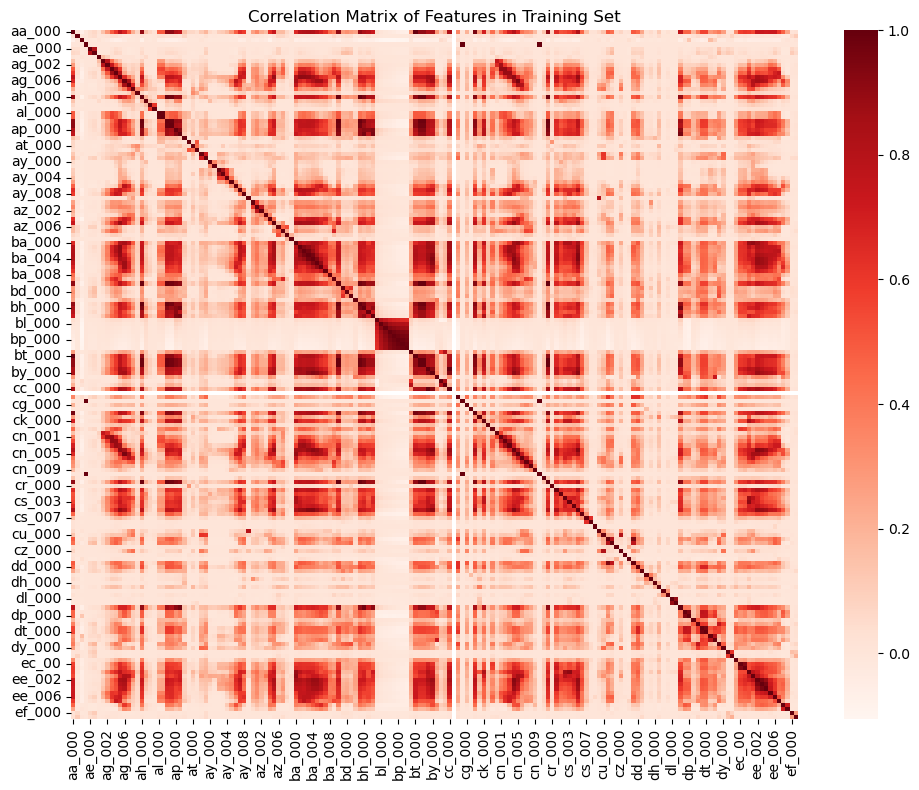

In [7]:
train_corr_matrix = aps_train_imputed.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(train_corr_matrix, cmap='Reds')
plt.title("Correlation Matrix of Features in Training Set")
plt.tight_layout()
plt.show()

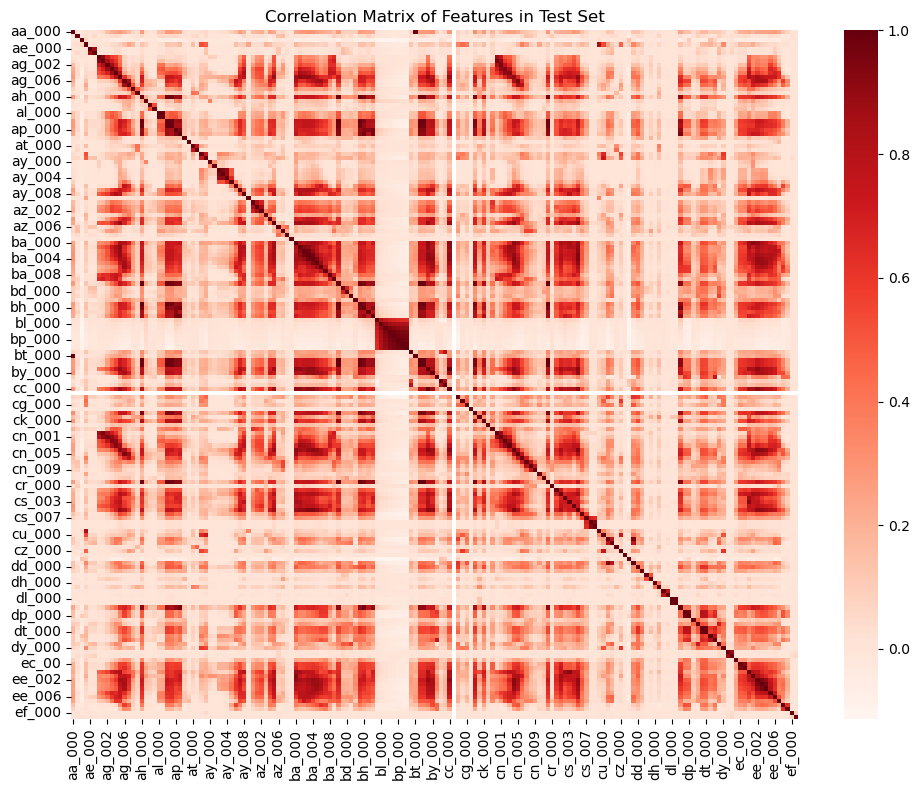

In [8]:
test_corr_matrix = aps_test_imputed.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(test_corr_matrix, cmap='Reds')
plt.title("Correlation Matrix of Features in Test Set")
plt.tight_layout()
plt.show()

#### (iv) Make scatter plots and box plots

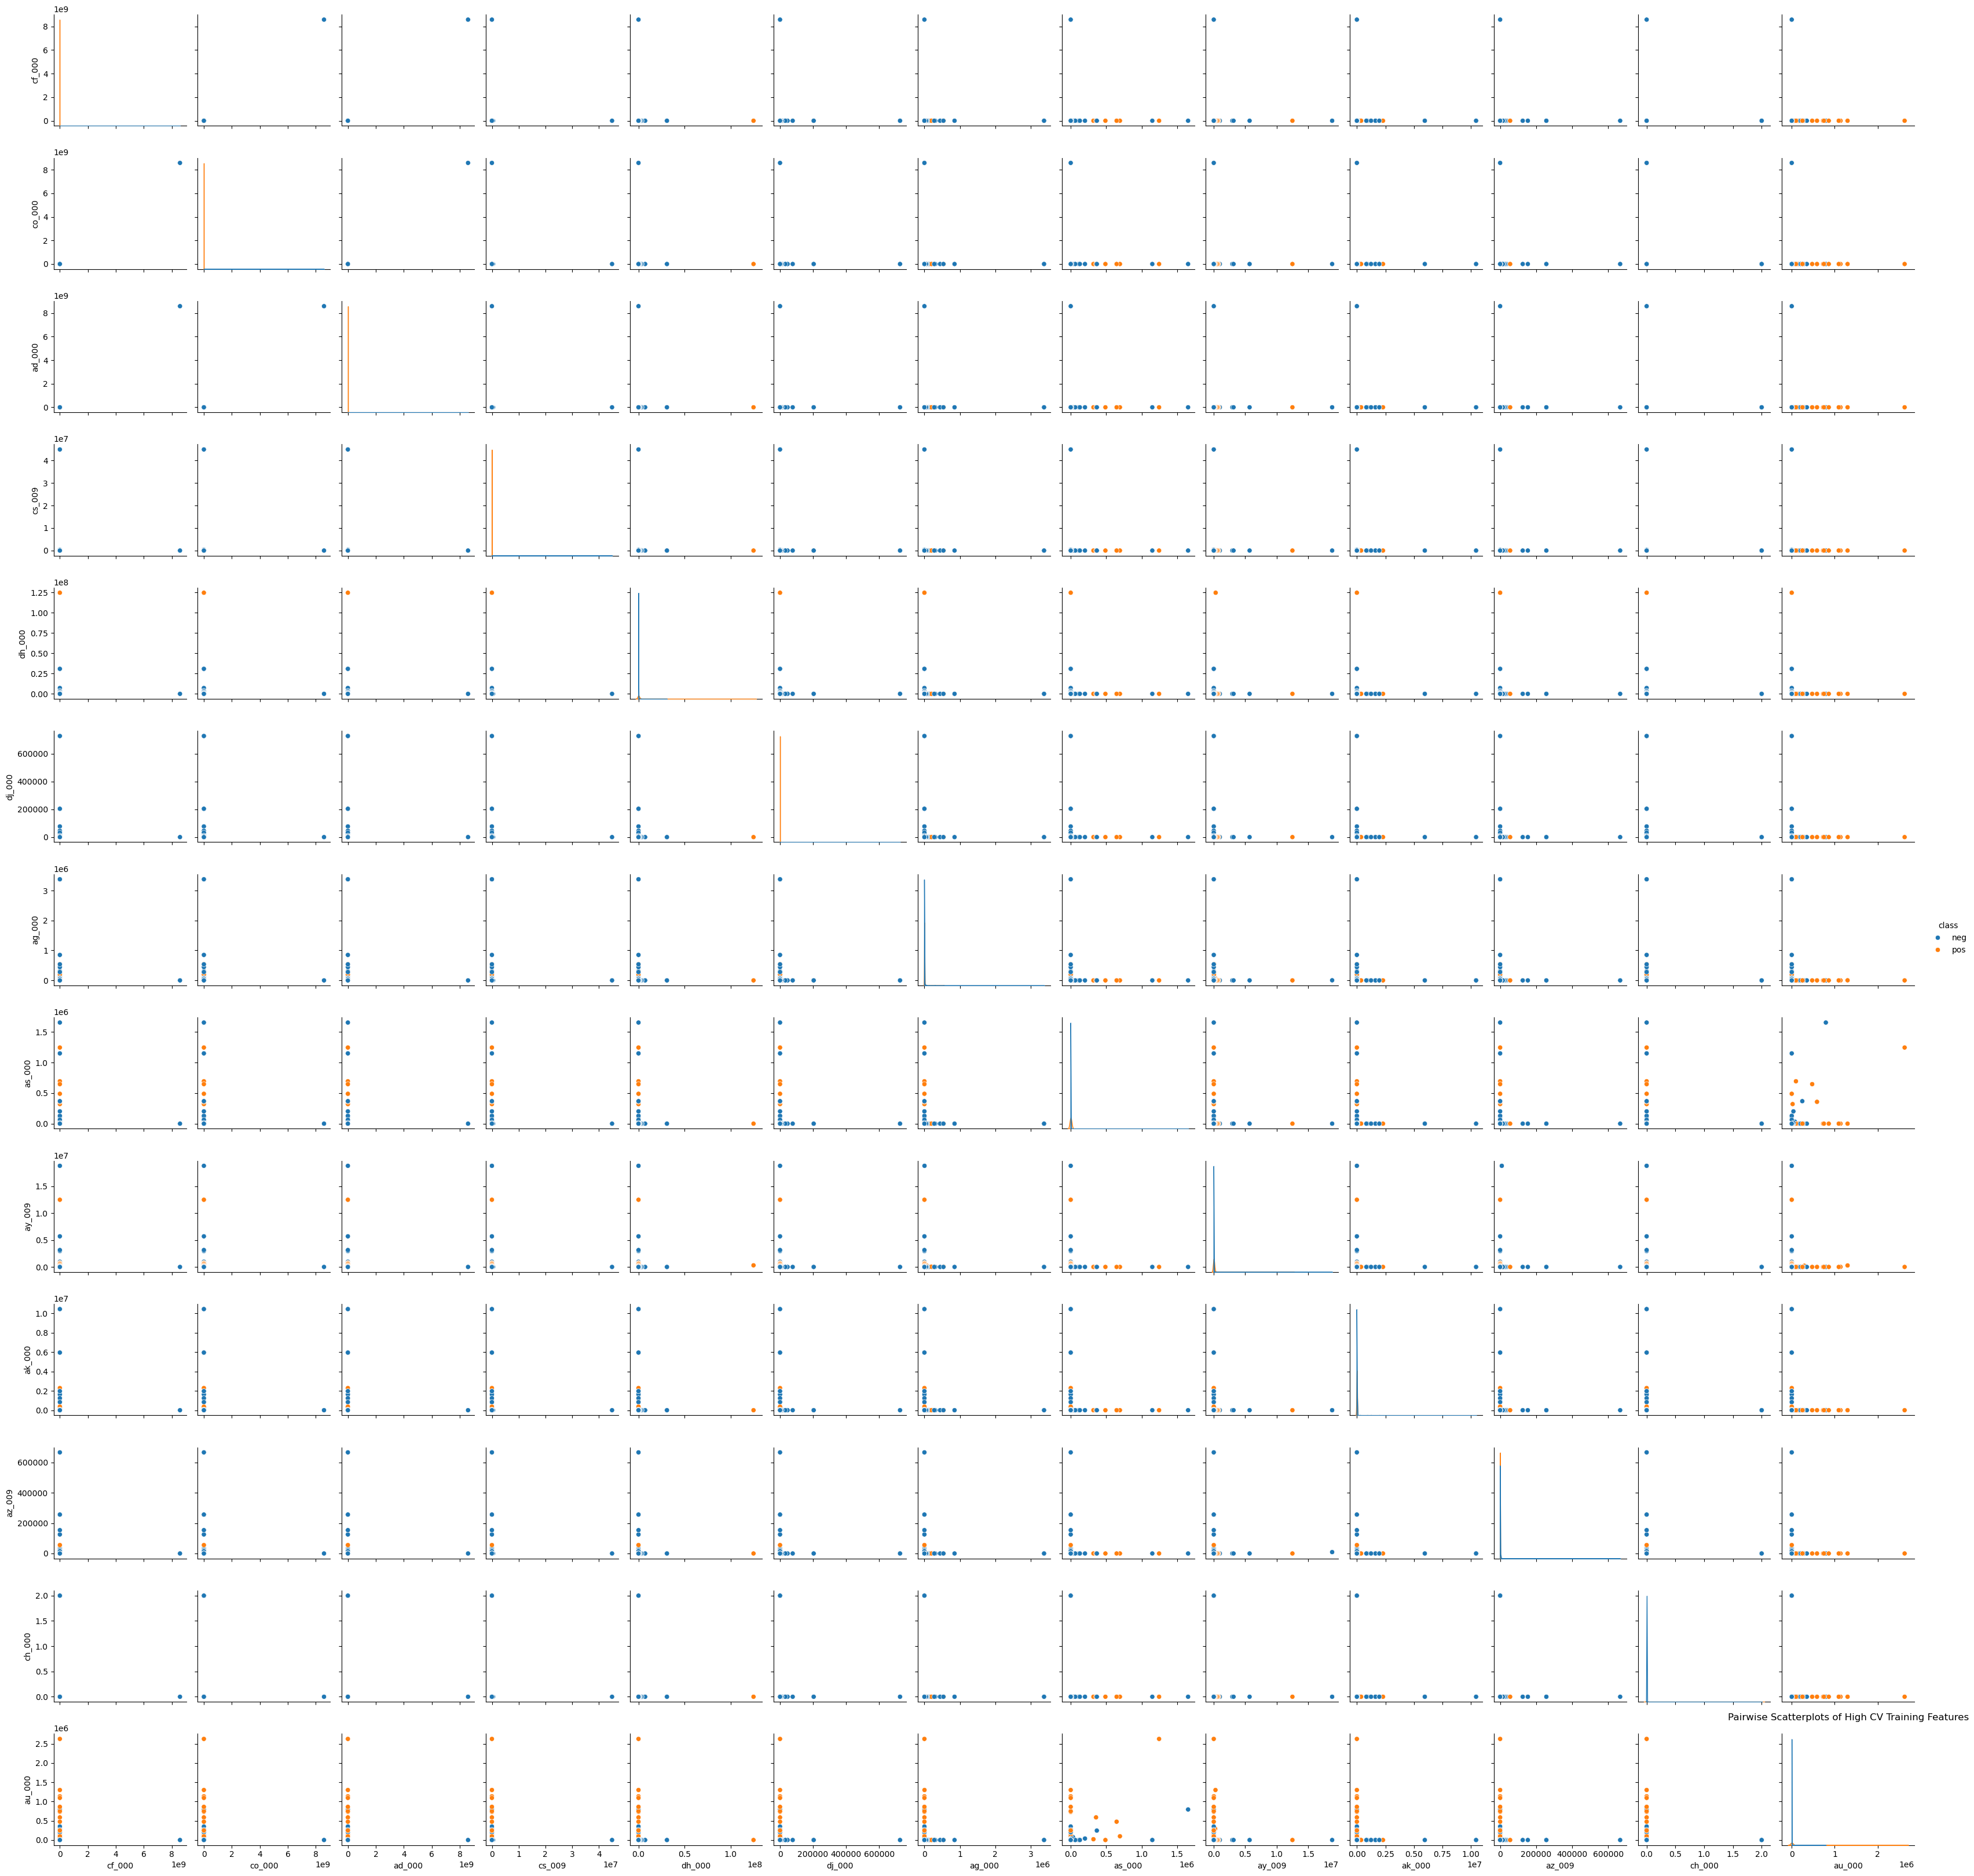

In [9]:
top_13_CV_train = train_CV_df.sort_values(by='CV', ascending=False).head(13).index.to_list()
aps_train_selected = aps_train_imputed.loc[:, top_13_CV_train]
aps_train_selected['class'] = aps_train_class
sns.pairplot(aps_train_selected, diag_kind='kde', hue='class')
plt.title('Pairwise Scatterplots of High CV Training Features')
plt.tight_layout()
plt.show()

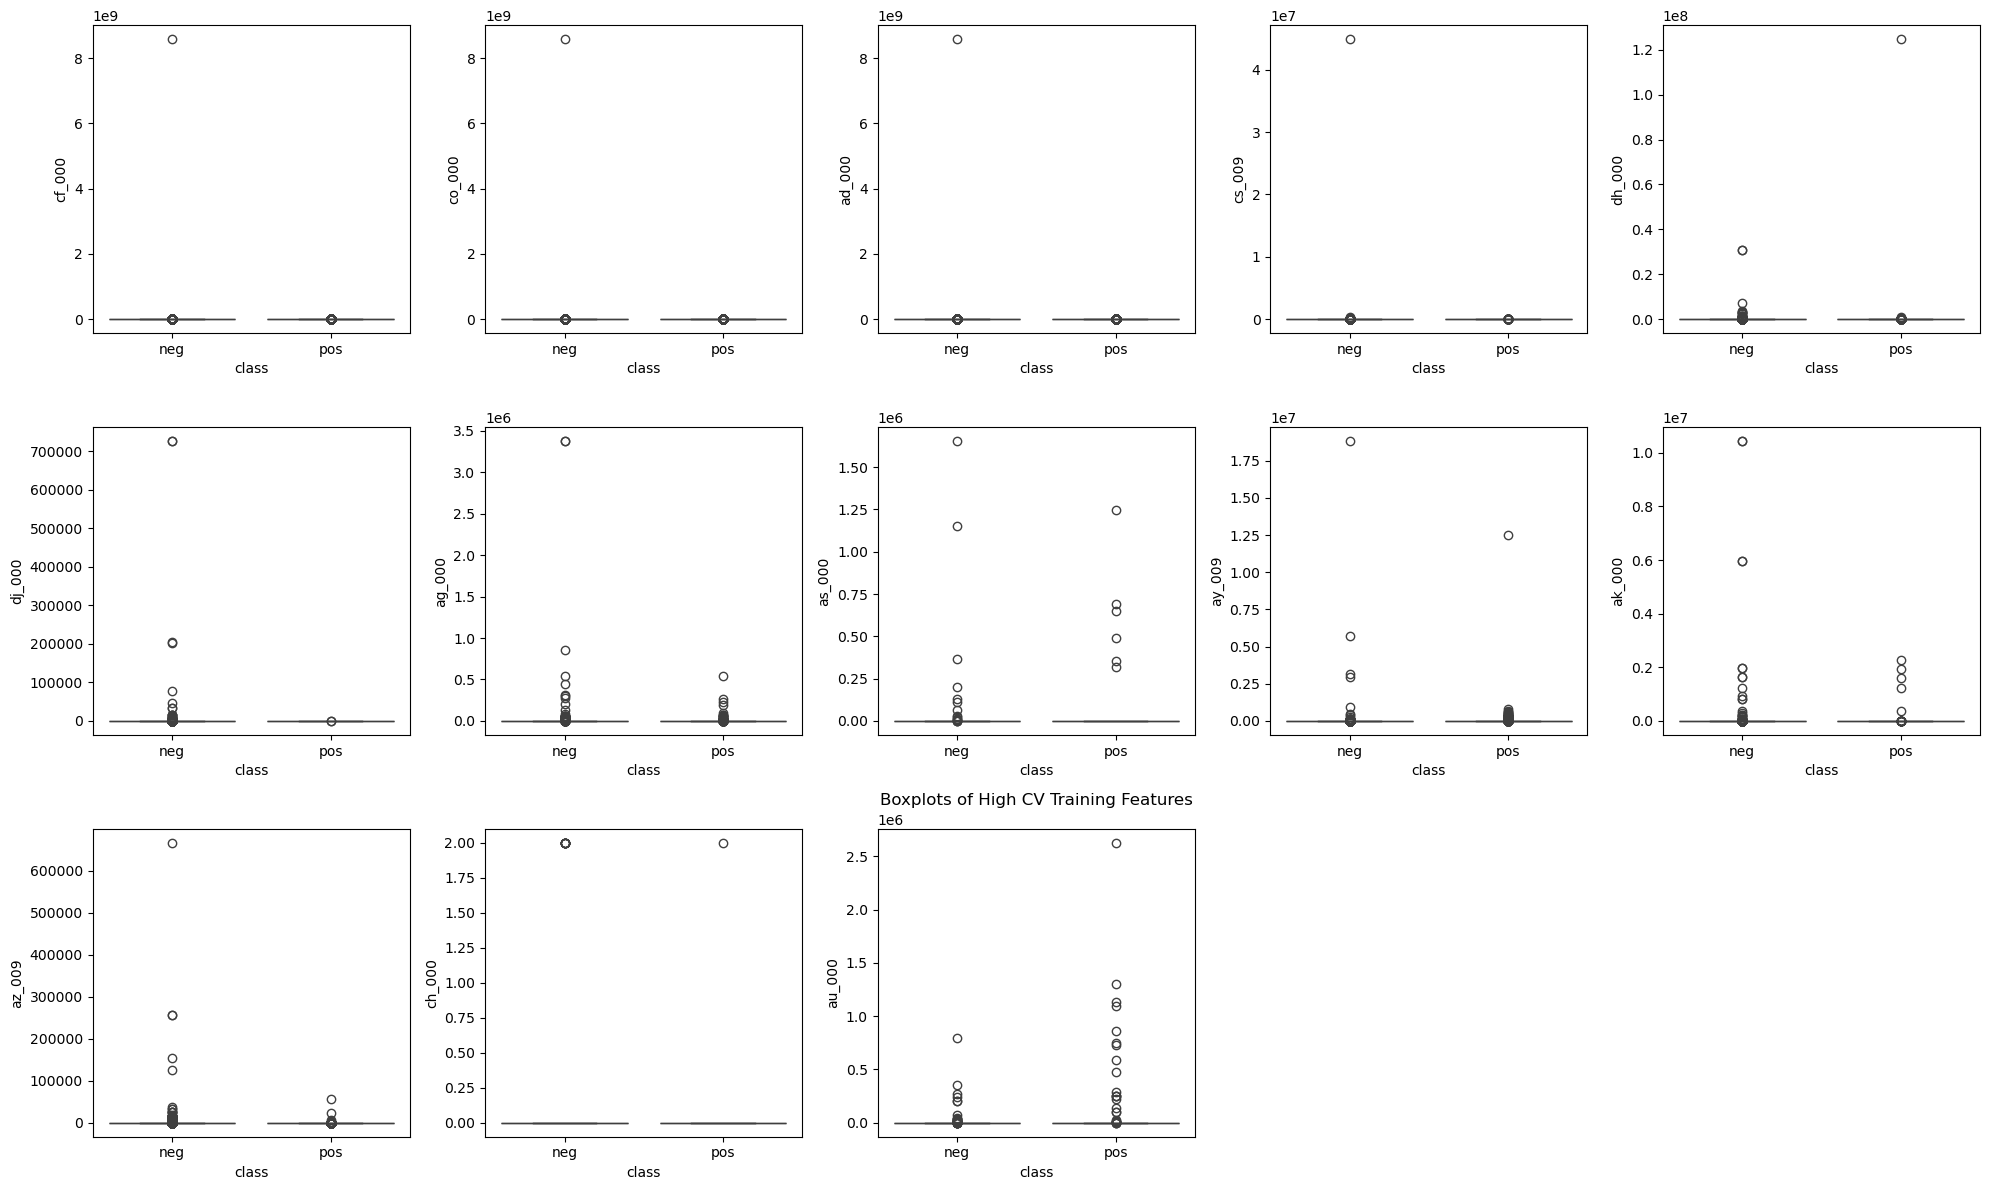

In [10]:
fig, axes = plt.subplots(3, 5, figsize=(20, 12))  
axes = axes.flatten()  

for i, feature in enumerate(aps_train_selected.columns[:-1]):  
    sns.boxplot(data=aps_train_selected, x='class', y=feature, ax=axes[i])

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.title('Boxplots of High CV Training Features')
plt.tight_layout()
plt.show()

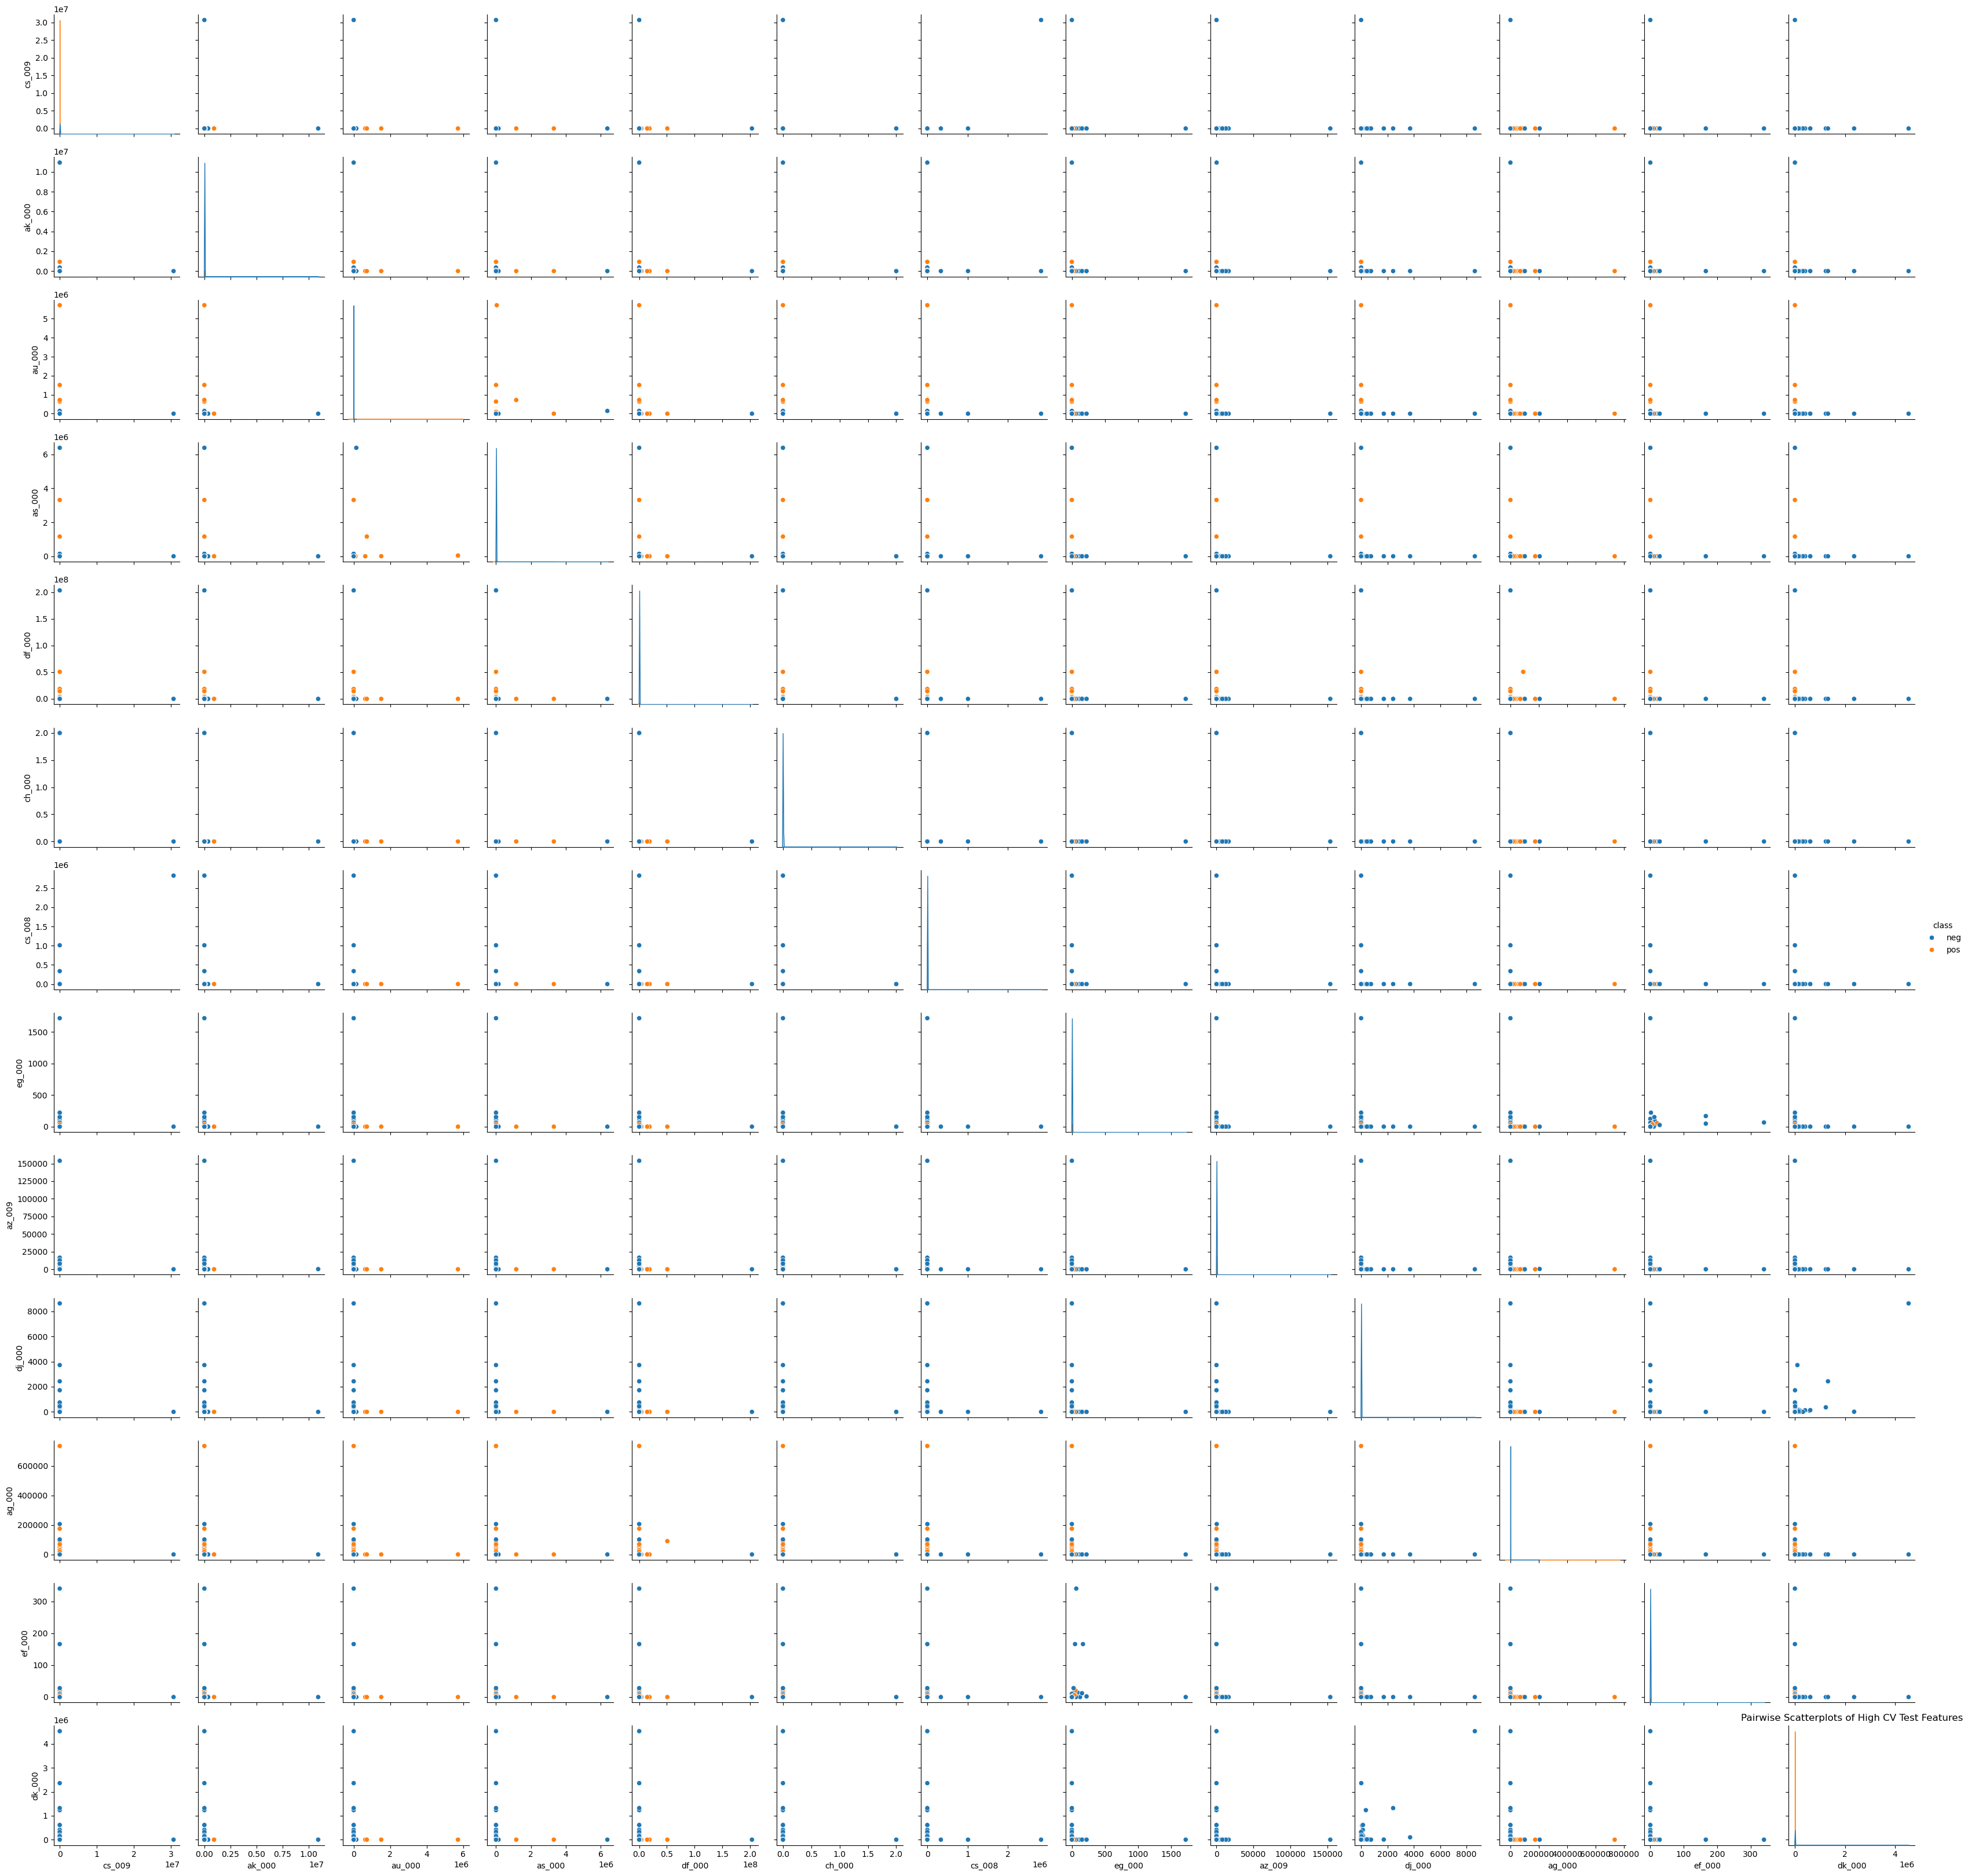

In [11]:
top_13_CV_test = test_CV_df.sort_values(by='CV', ascending=False).head(13).index.to_list()
aps_test_selected = aps_test_imputed.loc[:, top_13_CV_test]
aps_test_selected['class'] = aps_test_class
sns.pairplot(aps_test_selected, diag_kind='kde', hue='class')
plt.title('Pairwise Scatterplots of High CV Test Features')
plt.tight_layout()
plt.show()

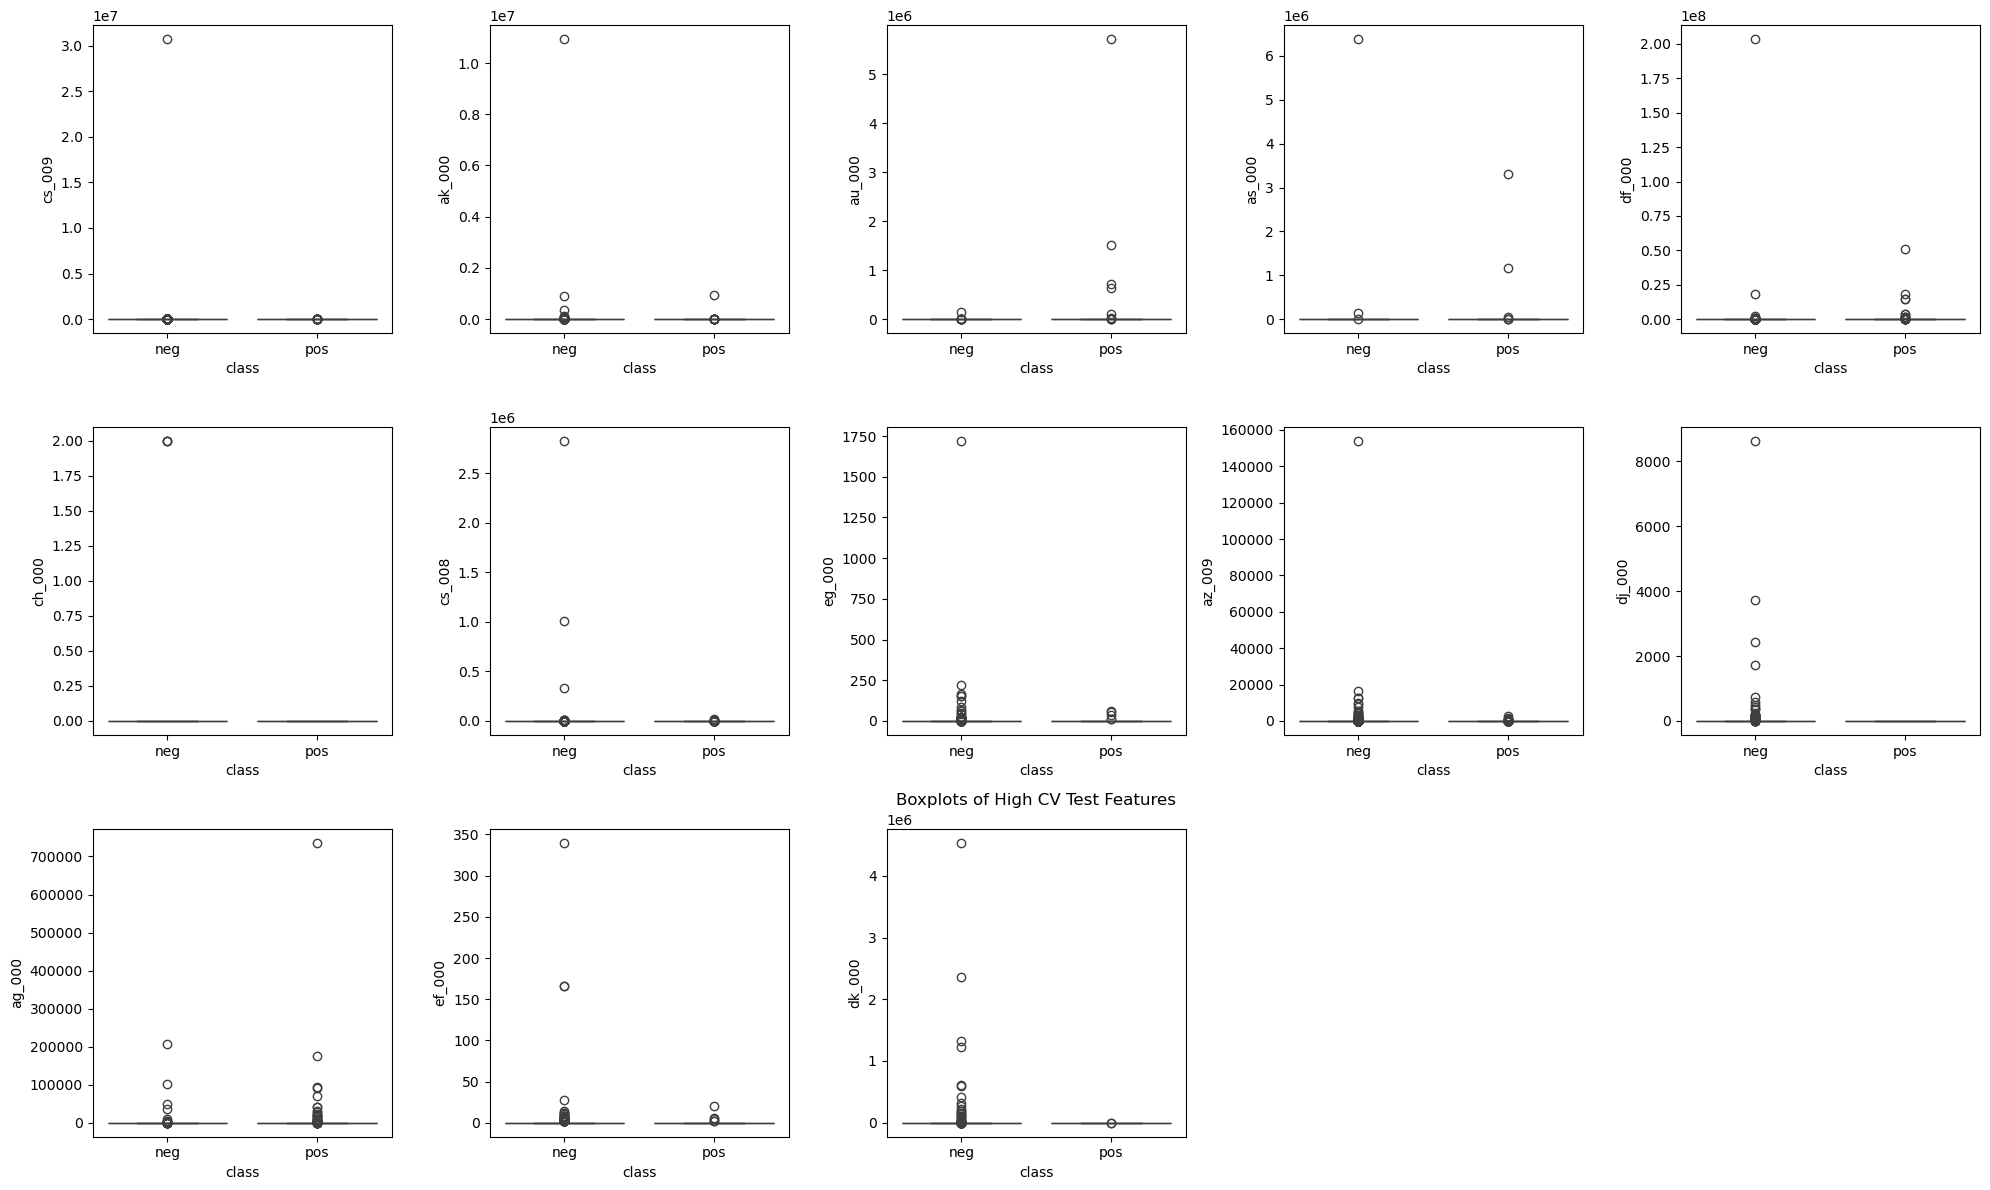

In [12]:
fig, axes = plt.subplots(3, 5, figsize=(20, 12))  
axes = axes.flatten()  

for i, feature in enumerate(aps_test_selected.columns[:-1]):  
    sns.boxplot(data=aps_test_selected, x='class', y=feature, ax=axes[i])

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.title('Boxplots of High CV Test Features')
plt.tight_layout()
plt.show()

Looking at the visualizations for the highest CV features in both the training and testing data we can see that there does not seem to be much variance in these features likely due to the fact that there were many missing values that were imputed with the median. However, while these scatterplots and boxplots do seem to be sparse in terms of the variance of the data points, I do expect a tree-based classifier to perform well because there does seem to be some separation between classes even though there does not appear to be many unique points to work off of. Although, it is difficult to analyze and compare the significance of these features simply by looking at the plots above as the distributions do not give too much insight due to the clear lack of variance. Further, looking at the scatterplots we can see that these features do have extreme values that could heavily skew the means which supports my choice of using median imputation for the missing values.  

#### (v) Is this data set imbalanced?

In [13]:
class_counts = aps_train_class.value_counts()
print(class_counts)

class
neg    59000
pos     1000
Name: count, dtype: int64


From the class counts above, it is clear that this dataset is imbalanced. 

### (c) Train a random forest

In [14]:
def evaluate_rf_model(X_train, X_test, y_train, y_test, rf):

    rf.fit(X_train, y_train)

    y_train_pred = rf.predict(X_train)
    y_test_pred = rf.predict(X_test)

    train_error = 1 - accuracy_score(y_train, y_train_pred)
    test_error = 1 - accuracy_score(y_test, y_test_pred)
    oob_error = 1 - rf.oob_score_

    print("Training Misclassification Rate:", train_error)
    print("Test Misclassification Rate:", test_error)
    print("Out-of-Bag Error Estimate:", oob_error)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    class_labels = ['neg', 'pos']
    
    train_conf_matrix = confusion_matrix(y_train, y_train_pred)
    train_disp = ConfusionMatrixDisplay(train_conf_matrix, display_labels=class_labels)
    train_disp.plot(ax=axes[0])
    axes[0].set_title("Training Confusion Matrix")
    
    test_conf_matrix = confusion_matrix(y_test, y_test_pred)
    test_disp = ConfusionMatrixDisplay(test_conf_matrix, display_labels=class_labels)
    test_disp.plot(ax=axes[1])
    axes[1].set_title("Test Confusion Matrix")
    
    plt.tight_layout()
    plt.show()

    y_train_pred_prob = rf.predict_proba(X_train)[:, 1]
    y_test_pred_prob = rf.predict_proba(X_test)[:, 1]
    
    train_auc = roc_auc_score(y_train, y_train_pred_prob)
    test_auc = roc_auc_score(y_test, y_test_pred_prob)
    
    train_fpr, train_tpr, train_thresholds = roc_curve(y_train, y_train_pred_prob, pos_label='pos')
    test_fpr, test_tpr, test_thresholds = roc_curve(y_test, y_test_pred_prob, pos_label='pos')
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    axes[0].plot(train_fpr, train_tpr, color='darkorange', lw=6, label=f'ROC Curve (area={train_auc:.4f})')
    axes[0].plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
    axes[0].set_xlim([0.0,1.0])
    axes[0].set_ylim([0.0,1.05])
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title('Training Random Forest ROC Curve')
    axes[0].legend(loc='lower right')
    
    axes[1].plot(test_fpr, test_tpr, color='darkorange', lw=6, label=f'ROC Curve (area={test_auc:.4f})')
    axes[1].plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
    axes[1].set_xlim([0.0,1.0])
    axes[1].set_ylim([0.0,1.05])
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('Test Random Forest ROC Curve')
    axes[1].legend(loc='lower right')
    
    plt.tight_layout()
    plt.show()

Training Misclassification Rate: 0.0
Test Misclassification Rate: 0.008062499999999972
Out-of-Bag Error Estimate: 0.006349999999999967


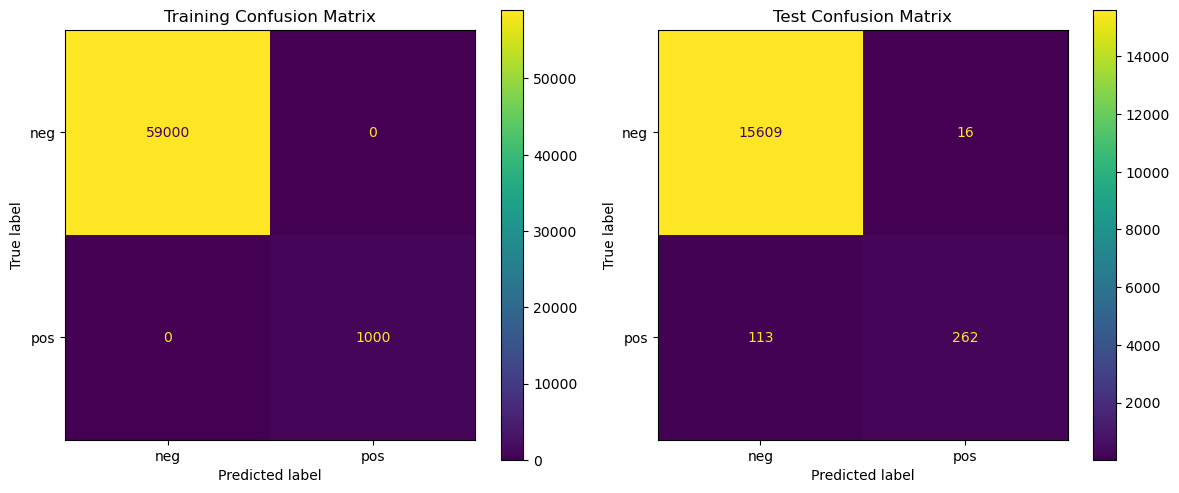

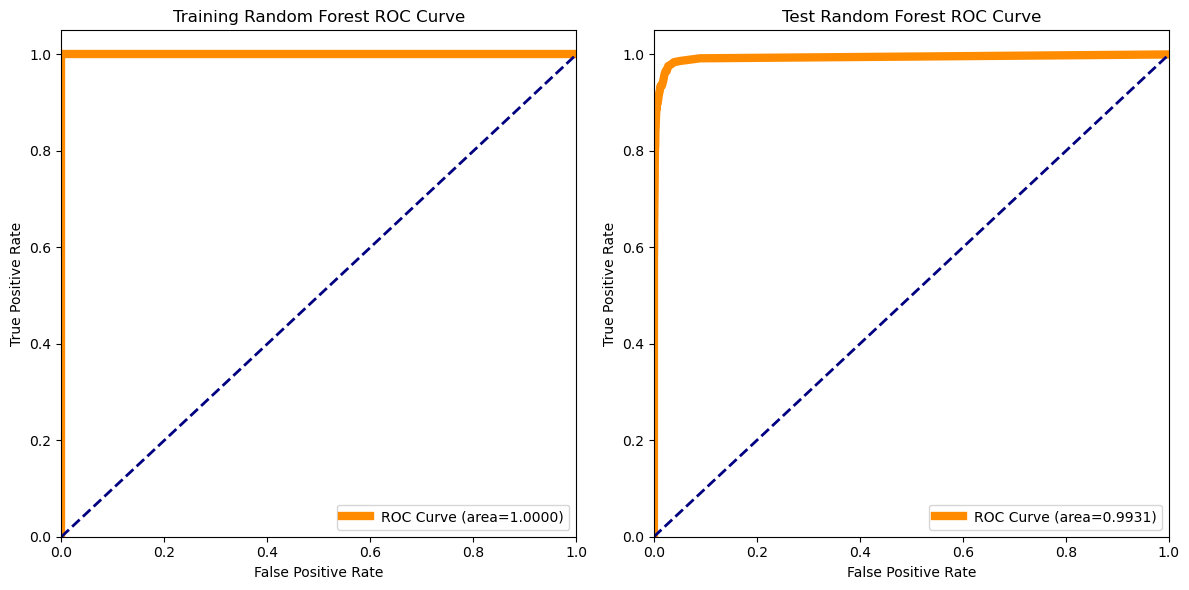

In [15]:
X_train = aps_train_imputed
y_train = aps_train_class
X_test = aps_test_imputed
y_test = aps_test_class
rf = RandomForestClassifier(oob_score=True, random_state=24)

evaluate_rf_model(X_train, X_test, y_train, y_test, rf)

Comparing the out-of-bag error to the true test error we can see that the estimate is fairly close to the true value, being off by only about 0.002 error rate. 

### (d) Research class imbalance in random forest

Training Misclassification Rate: 0.0
Test Misclassification Rate: 0.010687499999999961
Out-of-Bag Error Estimate: 0.0076666666666667105


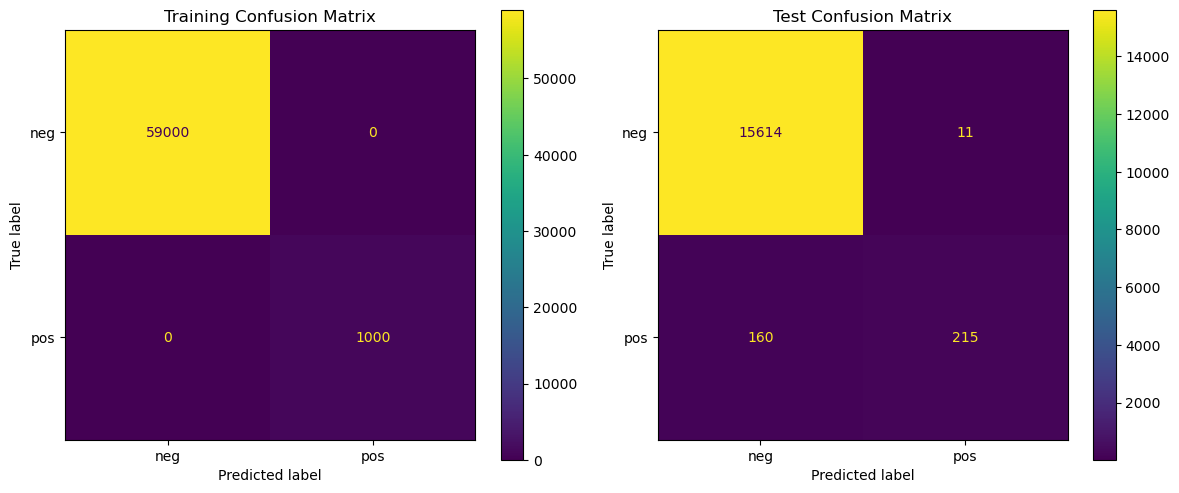

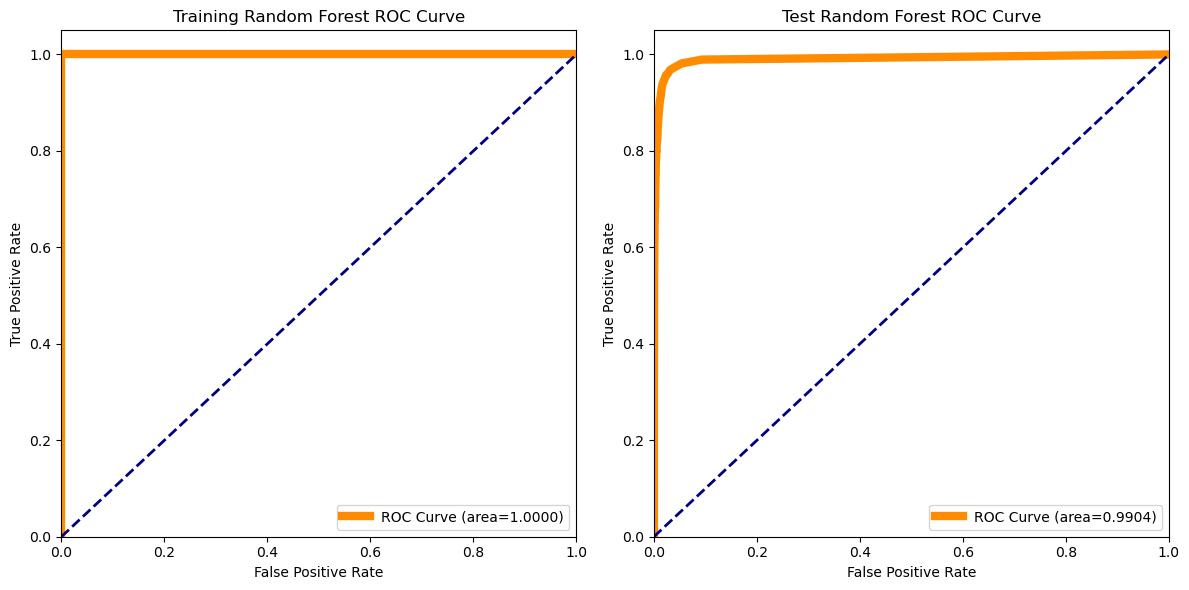

In [16]:
rf_balanced = RandomForestClassifier(class_weight="balanced", oob_score=True, random_state=24)
evaluate_rf_model(X_train, X_test, y_train, y_test, rf_balanced)

Again, the out-of-bag error estimate seems to be doing a decent job of estimating the true test error. However, interestingly when adjusting the class weights to compensate for class imbalance we get slightly worse performance with an error rate of about 0.01 when compensating for imbalance compared to the original error of 0.008 with no class balance adjustments. 

### (e) XGBoost and Model Trees

In [17]:
def find_best_alpha(X_train_set, y_train_set):
    cv_results = {0.01: [], 0.1: [], 1.0: [], 10.0: [], 100.0: []}
    param_grid = {'reg_alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
    outer_cv = KFold(n_splits=10, shuffle=True, random_state=24)
    
    for train_index, val_index in outer_cv.split(X_train_set):
        X_subtrain, X_val = X_train_set.iloc[train_index], X_train_set.iloc[val_index]
        y_subtrain, y_val = y_train_set.iloc[train_index], y_train_set.iloc[val_index]

        gbtree = XGBClassifier(booster='gbtree', objective='binary:logistic', eval_metric='logloss', random_state=24)
        grid_search = GridSearchCV(estimator=gbtree, param_grid=param_grid, scoring='f1', cv=5, n_jobs=-1)
        grid_search.fit(X_subtrain, y_subtrain)
    
        best_alpha = grid_search.best_params_['reg_alpha']
        gbtree_optimal = XGBClassifier(booster='gbtree', objective='binary:logistic', reg_alpha=best_alpha, eval_metric='logloss', random_state=24)
        gbtree_optimal.fit(X_subtrain, y_subtrain)
        y_val_pred = gbtree_optimal.predict(X_val)
        val_score = accuracy_score(y_val, y_val_pred)
        cv_results[best_alpha].append(val_score)
    
    results_data = []
    
    for alpha, scores in cv_results.items():
        num_times_chosen = len(scores)  
        mean_score = np.mean(scores) if scores else np.nan  
        results_data.append({'alpha': alpha, 'num_times_chosen': num_times_chosen, 'mean_f1_score': mean_score})
    
    results_df = pd.DataFrame(results_data)
    results_df = results_df.sort_values(by='alpha')
    return results_df    
    

def estimate_test_error(X_train_set, y_train_set, xgboost_best):  
    cv_results_5fold = cross_validate(estimator=xgboost_best, X=X_train_set, y=y_train_set, cv=5, scoring='accuracy', n_jobs=-1)
    accuracy_scores_5fold = cv_results_5fold['test_score']
    misclassification_errors_5fold = 1 - accuracy_scores_5fold
    
    cv_results_10fold = cross_validate(estimator=xgboost_best, X=X_train_set, y=y_train_set, cv=10, scoring='accuracy', n_jobs=-1)
    accuracy_scores_10fold = cv_results_10fold['test_score']
    misclassification_errors_10fold = 1 - accuracy_scores_10fold
    
    print('Mean 5-Fold Misclassification Error:', misclassification_errors_5fold.mean())
    print('Mean 10-Fold Misclassification Error:', misclassification_errors_10fold.mean())


def evaluate_xgboost(X_train_set, X_test_set, y_train_set, y_test_set, xgboost_best):  
    xgboost_best.fit(X_train_set, y_train_set)
    y_train_pred = xgboost_best.predict(X_train_set)
    y_test_pred = xgboost_best.predict(X_test_set)
    
    train_accuracy = accuracy_score(y_train_set, y_train_pred)
    test_accuracy = accuracy_score(y_test_set, y_test_pred)
    train_error = 1 - train_accuracy
    test_error = 1 - test_accuracy
    
    print('Train Misclassification Error:', train_error)
    print('Test Misclassification Error:', test_error)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    class_labels = ['neg', 'pos']
    
    train_conf_matrix = confusion_matrix(y_train_set, y_train_pred)
    train_disp = ConfusionMatrixDisplay(train_conf_matrix, display_labels=class_labels)
    train_disp.plot(ax=axes[0])
    axes[0].set_title("Training Confusion Matrix")
    
    test_conf_matrix = confusion_matrix(y_test_set, y_test_pred)
    test_disp = ConfusionMatrixDisplay(test_conf_matrix, display_labels=class_labels)
    test_disp.plot(ax=axes[1])
    axes[1].set_title("Test Confusion Matrix")
    
    plt.tight_layout()
    plt.show()

    y_train_pred_prob = xgboost_best.predict_proba(X_train_set)[:, 1]
    y_test_pred_prob = xgboost_best.predict_proba(X_test_set)[:, 1]
    
    train_auc = roc_auc_score(y_train_set, y_train_pred_prob)
    test_auc = roc_auc_score(y_test_set, y_test_pred_prob)
    
    train_fpr, train_tpr, train_thresholds = roc_curve(y_train_set, y_train_pred_prob)
    test_fpr, test_tpr, test_thresholds = roc_curve(y_test_set, y_test_pred_prob)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    axes[0].plot(train_fpr, train_tpr, color='darkorange', lw=6, label=f'ROC Curve (area={train_auc:.4f})')
    axes[0].plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
    axes[0].set_xlim([0.0,1.0])
    axes[0].set_ylim([0.0,1.05])
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title('Training Random Forest ROC Curve')
    axes[0].legend(loc='lower right')
    
    axes[1].plot(test_fpr, test_tpr, color='darkorange', lw=6, label=f'ROC Curve (area={test_auc:.4f})')
    axes[1].plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
    axes[1].set_xlim([0.0,1.0])
    axes[1].set_ylim([0.0,1.05])
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('Test Random Forest ROC Curve')
    axes[1].legend(loc='lower right')
    
    plt.tight_layout()
    plt.show()

In [18]:
y_train_encoded = y_train.replace({'neg': 0, 'pos': 1}).astype(int)
y_test_encoded = y_test.replace({'neg': 0, 'pos': 1}).astype(int)

find_best_alpha(X_train, y_train_encoded)

,alpha,num_times_chosen,mean_f1_score
0,0.01,3,0.993778
1,0.10,3,0.995944
2,1.00,4,0.994417
3,10.00,0,NaN
4,100.00,0,NaN


The best alpha here appears to be 1 because it was chosen the most out of the 10 folds. While it has a slightly lower mean F1 score then alpha=0.1, it is a negligible difference considering that alpha=1 was picked more. 

In [19]:
gbtree_best = XGBClassifier(booster='gbtree', objective='binary:logistic', reg_alpha=1, eval_metric='logloss', random_state=24)
estimate_test_error(X_train, y_train_encoded, gbtree_best)

Mean 5-Fold Misclassification Error: 0.0054666666666666865
Mean 10-Fold Misclassification Error: 0.005433333333333313


Train Misclassification Error: 1.666666666666483e-05
Test Misclassification Error: 0.006000000000000005


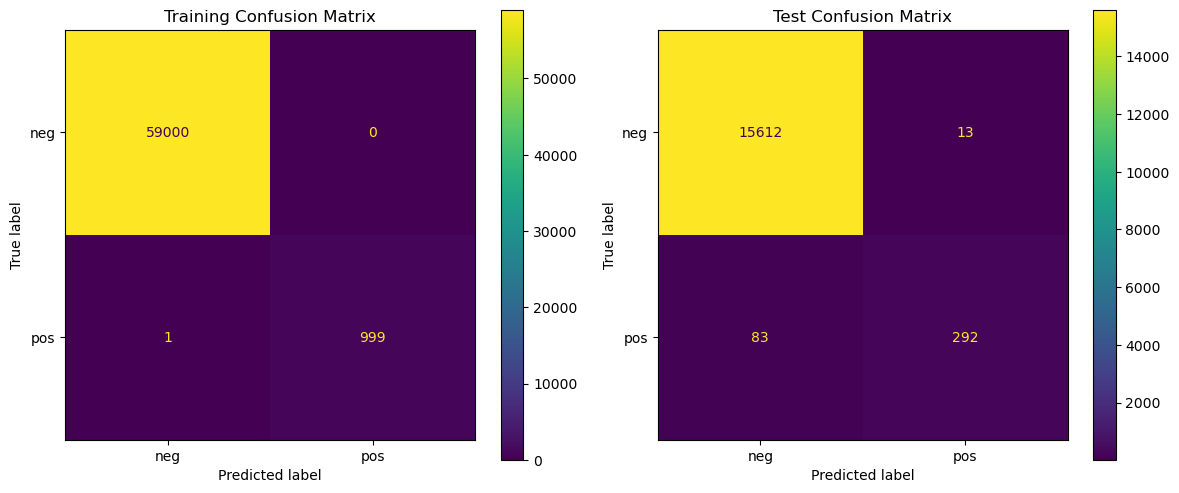

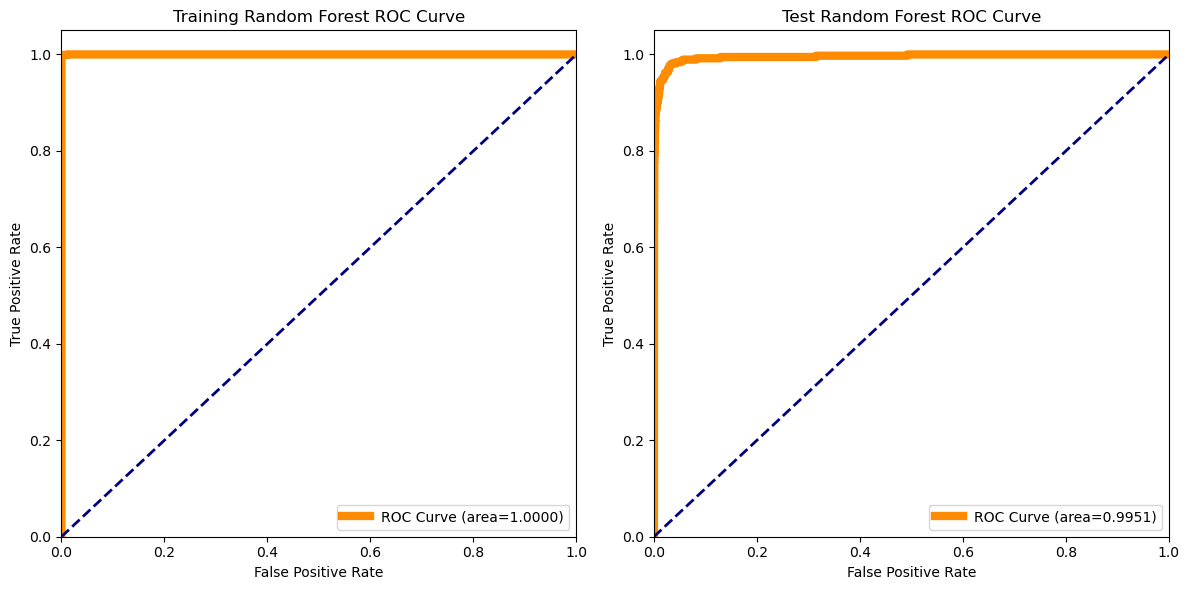

In [20]:
evaluate_xgboost(X_train, X_test, y_train_encoded, y_test_encoded, gbtree_best)

We can see that the 5 and 10-fold cross-validation error estimates are quite accurate and can estimate the test error even better than the out-of-bag error estimates from earlier. 

### (f) Use SMOTE to pre-process your data

In [21]:
smote = SMOTE(random_state=24)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train_encoded)

In [22]:
find_best_alpha(X_train_balanced, y_train_balanced)

,alpha,num_times_chosen,mean_f1_score
0,0.01,3,0.997514
1,0.10,6,0.997910
2,1.00,1,0.998220
3,10.00,0,NaN
4,100.00,0,NaN


Here, it looks like an alpha of 0.10 is best because it was chosen the most times and the difference in the mean score compared to the other alpha levels is not enough to compensate for the fact that the mean score is slightly lower. 

In [23]:
xgboost_best = XGBClassifier(booster='gbtree', objective='binary:logistic', reg_alpha=0.1, eval_metric='logloss', random_state=24)
estimate_test_error(X_train_balanced, y_train_balanced, xgboost_best)

Mean 5-Fold Misclassification Error: 0.0025423728813559255
Mean 10-Fold Misclassification Error: 0.0022966101694915086


Train Misclassification Error: 1.694915254235596e-05
Test Misclassification Error: 0.006937500000000041


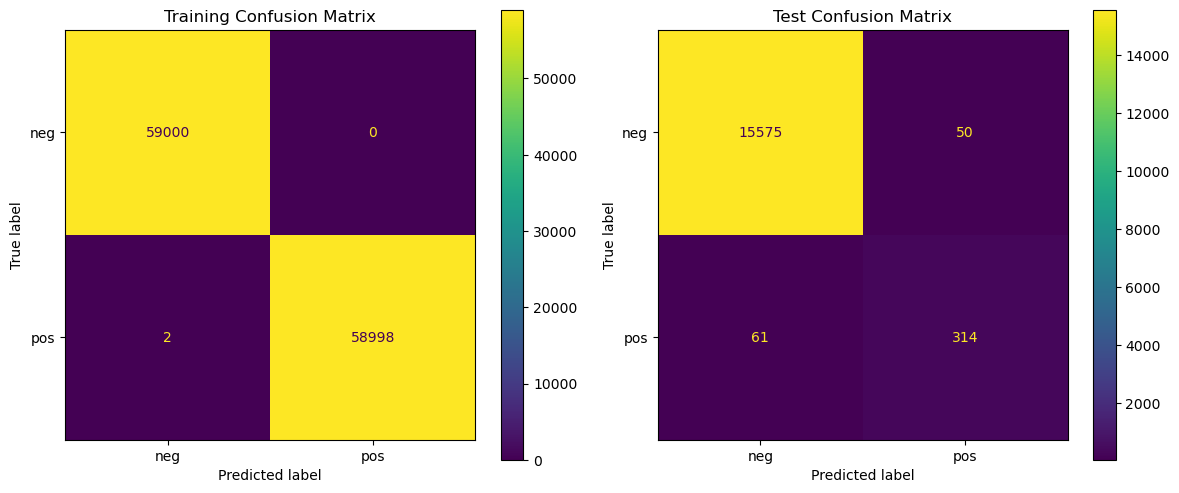

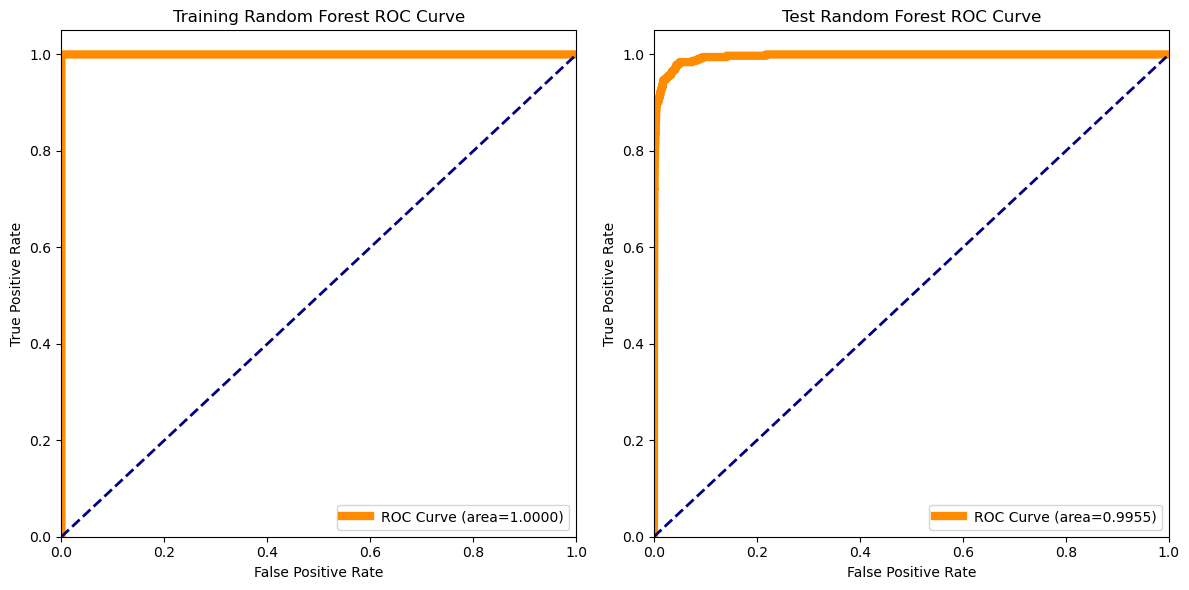

In [24]:
evaluate_xgboost(X_train_balanced, X_test, y_train_balanced, y_test_encoded, xgboost_best)